In [2]:
import mne

raw = mne.io.read_raw_edf("sub-104_task-Sleep_acq-psg_eeg.edf", preload=True)

print(raw.info)
raw.plot()

Extracting EDF parameters from sub-104_task-Sleep_acq-psg_eeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6443519  =      0.000 ... 25169.996 secs...


C:\Users\Joanna\AppData\Local\Temp\ipykernel_36096\3623366037.py:3: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf("sub-104_task-Sleep_acq-psg_eeg.edf", preload=True)


<Info | 8 non-empty values
 bads: []
 ch_names: PSG_F3, PSG_F4, PSG_C3, PSG_C4, PSG_O1, PSG_O2, PSG_EOGL, ...
 chs: 16 EEG
 custom_ref_applied: False
 highpass: 0.1 Hz
 lowpass: 128.0 Hz
 meas_date: 2024-06-25 23:42:56 UTC
 nchan: 16
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: sub-104>
>
Using qt as 2D backend.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x258a0669db0) at 0x00000258A67C5840>

Channels marked as bad:
none


In [1]:
import numpy as np
import mne

edf_path = r"sub-104_task-Sleep_acq-psg_eeg.edf"
raw = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")

ch = "PSG_PULSE"   # change if needed
x = raw.get_data(picks=[ch]).squeeze()
sfreq = raw.info["sfreq"]

print("Channel:", ch)
print("Sampling rate (Hz):", sfreq)
print("dtype:", x.dtype)
print("n_samples:", x.size)
print("min / max:", np.min(x), np.max(x))
print("mean / std:", np.mean(x), np.std(x))

# show the first 50 samples (raw numbers)
print("\nFirst 50 samples:")
print(x[:50])

# how many distinct values in the first 10 seconds?
n10 = int(10 * sfreq)
uniq = np.unique(x[:n10])
print("\nUnique values in first 10 seconds:", uniq.size)

# show a small list of unique values (don’t spam the terminal)
print("First 30 unique values:", uniq[:30])

# how often does it change?
changes = np.sum(np.diff(x[:n10]) != 0)
print("\n# of value changes in first 10 seconds:", changes)

# show step sizes (if it's a counter/event signal, steps will be big or fixed)
steps = np.diff(x[:n10])
print("Most common step sizes (top 10):")
vals, counts = np.unique(steps, return_counts=True)
idx = np.argsort(counts)[::-1]
for v, c in list(zip(vals[idx], counts[idx]))[:10]:
    print(f"  step {v: .3f} : {c} times")


Channel: PSG_PULSE
Sampling rate (Hz): 256.0
dtype: float64
n_samples: 6443520
min / max: -274.4592676050965 193.32742687113753
mean / std: -63.229495203049545 43.97641582210514

First 50 samples:
[  40.25693736   95.15694118  113.54457626   40.25693736   35.20768349
   26.01386595   31.68944381   44.30871229  -63.23343603  -67.47078843
  -67.20015461  -67.47078843  -78.11056382 -174.30155642 -168.62597856
 -175.02066915 -175.02066915 -179.25802155 -254.62567468 -243.63020912
 -232.27132101 -226.58801076 -233.43891264 -274.45926761 -244.61995567
 -229.92840536 -217.21634813 -207.48126295 -212.88620699 -186.83576856
 -167.8140771  -150.94972381 -132.38424365 -111.91659434 -101.64024151
  -87.845649    -69.09459136  -50.5291112   -19.51447524  -36.64172995
  -31.77805356  -21.40891199   -7.25089693   19.78928805  -30.15425063
  -32.94564519  -28.88613787  -22.12802472   -7.16584058  -81.45095842]

Unique values in first 10 seconds: 1586
First 30 unique values: [-274.45926761 -254.6256746

In [2]:
import pandas as pd

df = pd.read_parquet("data/features/sub-102/psg/features.parquet")
print(df.shape)
print(df.columns[:20])
display(df.head())
print(df["stage_hum"].value_counts().sort_index())

(963, 19)
Index(['subject', 'acq', 'epoch_idx', 'onset', 'duration', 'stage_hum',
       'eeg_bp_delta', 'eeg_bp_theta', 'eeg_bp_alpha', 'eeg_bp_sigma',
       'eeg_bp_beta', 'ppg_bad_epoch', 'ppg_bad_reason', 'ppg_RMSSD',
       'ppg_SDNN', 'ppg_HR_mean_bpm', 'ppg_n_beats', 'ppg_pulse_amp_mean',
       'ppg_pulse_amp_std'],
      dtype='str')


,subject,acq,epoch_idx,onset,duration,stage_hum,eeg_bp_delta,eeg_bp_theta,eeg_bp_alpha,eeg_bp_sigma,eeg_bp_beta,ppg_bad_epoch,ppg_bad_reason,ppg_RMSSD,ppg_SDNN,ppg_HR_mean_bpm,ppg_n_beats,ppg_pulse_amp_mean,ppg_pulse_amp_std
0,sub-102,psg,0,0.0,30.0,0,0.788857,0.021614,0.014863,0.021614,0.147418,False,,16.259616,17.473321,98.609480,48,0.507754,0.027990
1,sub-102,psg,1,30.0,30.0,0,0.589600,0.046905,0.062130,0.081001,0.211138,False,,89.447191,94.026055,100.010852,49,0.582623,0.007489
2,sub-102,psg,2,60.0,30.0,0,0.665408,0.067096,0.068095,0.046478,0.143944,False,,139.368233,104.875831,103.295225,51,0.017916,0.000196
3,sub-102,psg,3,90.0,30.0,0,0.578980,0.050927,0.089056,0.064062,0.209535,False,,16.214075,27.168804,101.052632,50,-0.227768,0.001280
4,sub-102,psg,4,120.0,30.0,0,0.435379,0.052333,0.160945,0.062437,0.278956,False,,17.354977,36.059674,97.741673,48,0.446095,0.003334


stage_hum
0    198
1     35
2    681
4     49
Name: count, dtype: int64


In [3]:
df2 = pd.read_parquet("data/features/sub-102/headband/features.parquet")
print(df2.shape)
print(df2.columns[:20])
display(df2.head())
print(df2["stage_hum"].value_counts().sort_index())

(963, 11)
Index(['subject', 'acq', 'epoch_idx', 'onset', 'duration', 'stage_hum',
       'bp_delta', 'bp_theta', 'bp_alpha', 'bp_sigma', 'bp_beta'],
      dtype='str')


,subject,acq,epoch_idx,onset,duration,stage_hum,bp_delta,bp_theta,bp_alpha,bp_sigma,bp_beta
0,sub-102,headband,0,0.0,30.0,0,0.938128,0.036777,0.006950,0.001830,0.011056
1,sub-102,headband,1,30.0,30.0,0,0.919816,0.055633,0.005403,0.002195,0.012005
2,sub-102,headband,2,60.0,30.0,0,0.940418,0.038075,0.006248,0.003049,0.009053
3,sub-102,headband,3,90.0,30.0,0,0.971026,0.018186,0.002415,0.001116,0.004698
4,sub-102,headband,4,120.0,30.0,0,0.929491,0.014995,0.017645,0.003675,0.032352


stage_hum
0    198
1     35
2    681
4     49
Name: count, dtype: int64


In [4]:
import numpy as np
import matplotlib.pyplot as plt

S = np.load("data/features/sub-102/psg/spectrogram.npy")  # (N, C, F, T)
print(S.shape, S.dtype)

# show one epoch + one channel
ep = 0

(963, 6, 30, 117) float32


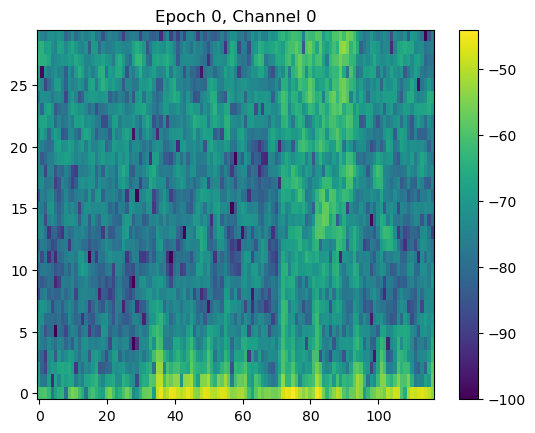

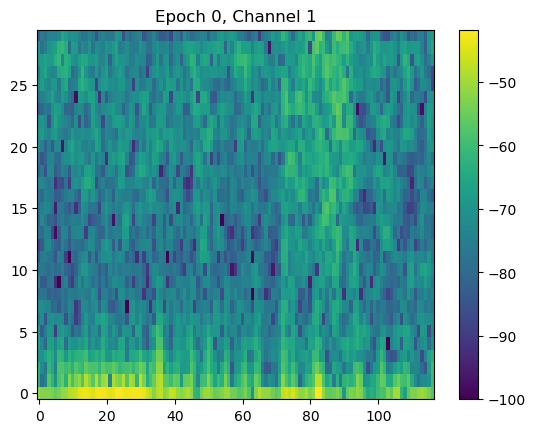

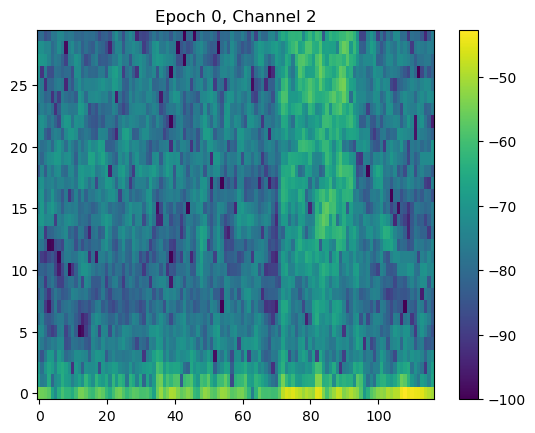

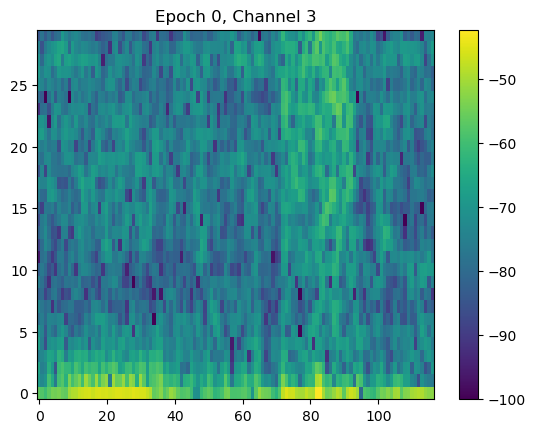

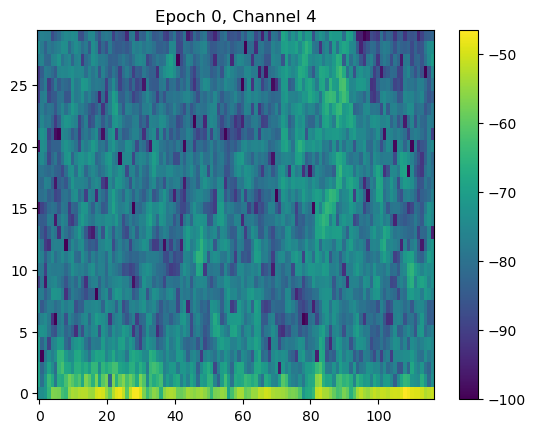

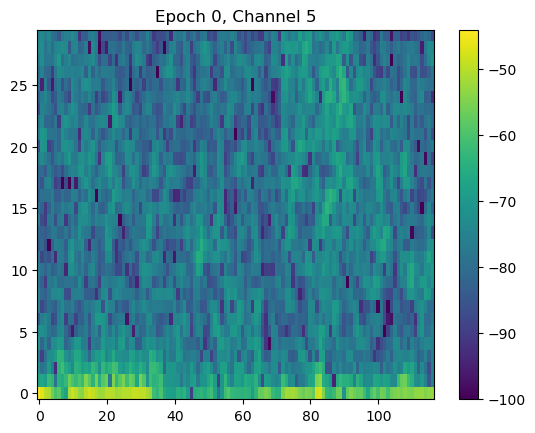

In [5]:
ep = 0
for ch in range(S.shape[1]):
    plt.figure()
    plt.imshow(S[ep, ch], aspect="auto", origin="lower")
    plt.title(f"Epoch {ep}, Channel {ch}")
    plt.colorbar()
    plt.show()

(963, 2, 30, 117) float32


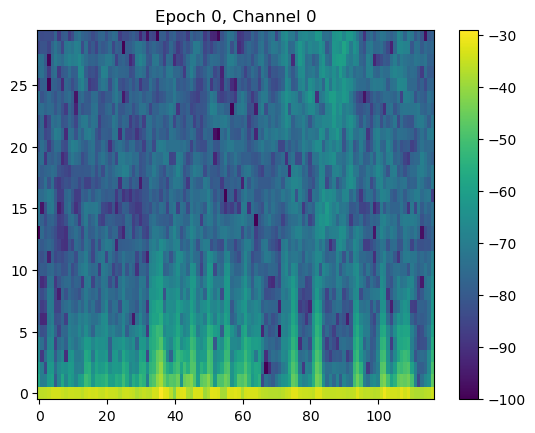

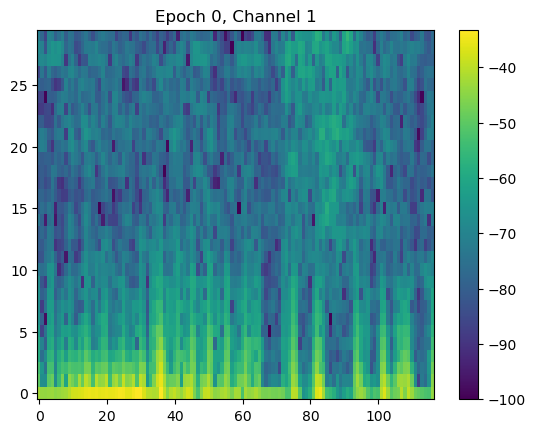

In [6]:
import numpy as np
import matplotlib.pyplot as plt

S2 = np.load("data/features/sub-102/headband/spectrogram.npy")  # (N, C, F, T)
print(S2.shape, S2.dtype)

# show one epoch + one channel
ep = 0
for ch in range(S2.shape[1]):
    plt.figure()
    plt.imshow(S2[ep, ch], aspect="auto", origin="lower")
    plt.title(f"Epoch {ep}, Channel {ch}")
    plt.colorbar()
    plt.show()